# Exploration et pré-traitement de la base de soudures

**Objectif.** Couvrir les deux premières étapes de la consigne : analyse descriptive et pré-traitement justifié de la base, puis choix des cibles et de la stratégie de prédiction. Le notebook produit la table nettoyée `data/cleaned/cleaned.csv`, les outils de préparation communs aux modèles (`preprocessing/ml_dataset.py`) et les figures de la partie Données du rapport.

**Exécution.** Depuis la racine du projet, de haut en bas. Les données sont téléchargées automatiquement si besoin ; les figures de `report/figures/` sont régénérées.

**Sommaire**
1. Comprendre le problème et les données : 1.1 De la soudure au problème d'apprentissage · 1.2 Téléchargement et lecture
2. Exploration des données brutes : 2.1 Choix des colonnes · 2.2 Diagnostic des entrées · 2.3 Analyses complémentaires · 2.4 Bilan
3. Pré-traitement : 3.1 `<x` · 3.2 Azote · 3.3 `150-200` · 3.4 Catégorielles · 3.5 Traitements inconnus · 3.6 Assemblage · 3.7 Éléments d'alliage non rapportés
4. Préparation pour la modélisation
5. Analyse descriptive des données nettoyées
6. Bilan et suite

# 1. Comprendre le problème et les données

## 1.1 De la soudure au problème d'apprentissage

Le **cordon** de soudure est le métal fondu puis solidifié qui relie deux pièces d'acier. Sa qualité se juge sur trois propriétés, mesurées par des essais destructifs sur des éprouvettes découpées dans le métal soudé :
- **résistance** et **ductilité** : essai de traction (limite d'élasticité, résistance à la traction, allongement, striction) ;
- **ténacité** : essai Charpy, énergie absorbée par un barreau entaillé cassé à une température donnée.

La base rassemble 1652 essais tirés de 46 articles. **Une ligne = une éprouvette** : colonnes 1 à 30, la recette (composition, paramètres de soudage, traitement thermique) ; colonnes 31 à 43, les résultats d'essais ; colonne 44, l'identifiant (`Weld ID`).

**Problème d'apprentissage** : régression, avec X = la recette et y = les propriétés mesurées. Il n'y a pas d'étiquette « bonne / mauvaise soudure » : une classification demanderait des seuils tirés d'une norme.

## 1.2 Téléchargement et lecture

- **Téléchargement** : `fetch_welddb()` récupère `welddb.tar` et en extrait `welddb.data` (données), `welddb.info` et `welddb.tex` (documentation) dans `data/welddb/`, s'ils sont absents. Les données ne sont pas versionnées dans Git.
- **Lecture** : `welddb.data` n'a pas d'en-tête ; les noms de colonnes viennent de `context/columns.json`, fichier de métadonnées (unité, type, rôle, valeurs manquantes, particularités de chaque colonne). `N` signale une valeur non renseignée.

**Constat** : 1652 lignes × 44 colonnes, aucun doublon, beaucoup de valeurs manquantes (jusqu'à 98 % pour une colonne).

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd

In [2]:
# Téléchargement automatique du jeu de données
# Ne fait rien si data/welddb/welddb.data existe déjà.
import tarfile
import urllib.request

WELDDB_URL = "https://www.phase-trans.msm.cam.ac.uk/map/data/tar/welddb.tar"
WELDDB_PATH = Path("data/welddb")


def fetch_welddb(url=WELDDB_URL, path=WELDDB_PATH):
    if (path / "welddb.data").exists():
        return
    path.mkdir(parents=True, exist_ok=True)
    tar_path = path / "welddb.tar"
    urllib.request.urlretrieve(url, tar_path)
    with tarfile.open(tar_path) as tar:
        for member in tar.getmembers():
            nom = Path(member.name).name
            if member.isfile() and nom.startswith("welddb."):
                (path / nom).write_bytes(tar.extractfile(member).read())
    tar_path.unlink()
    if not (path / "welddb.data").exists():
        raise FileNotFoundError("welddb.data introuvable dans l'archive")


fetch_welddb()

In [3]:
# N est le code utilisé dans le fichier pour signaler une valeur non renseignée.
colonnes = json.loads(Path("context/columns.json").read_text(encoding="utf-8"))
noms_colonnes = [
    f"{numero}. {infos['label']}"
    for numero, infos in sorted(colonnes.items(), key=lambda element: int(element[0]))
]

df = pd.read_csv(
    Path("data/welddb/welddb.data"),
    sep=r"\s+",
    header=None,
    names=noms_colonnes,
    na_values=["N"],
)

print(f"Dimensions de la base : {df.shape[0]} lignes et {df.shape[1]} colonnes")
display(df.head())

# Lignes identiques sur toutes les colonnes
lignes_dupliquees = df[df.duplicated(keep=False)]
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")
display(lignes_dupliquees)

# Valeurs manquantes par colonne et colonnes complètement vides
valeurs_manquantes = df.isna().sum().sort_values(ascending=False)
print("Valeurs manquantes par colonne :")
display(valeurs_manquantes[valeurs_manquantes > 0])

colonnes_vides = df.columns[df.isna().all()].tolist()
print("Colonnes complètement vides :", colonnes_vides)


Dimensions de la base : 1652 lignes et 44 colonnes


,1. Carbon concentration,2. Silicon concentration,3. Manganese concentration,4. Sulphur concentration,5. Phosphorus concentration,6. Nickel concentration,7. Chromium concentration,8. Molybdenum concentration,9. Vanadium concentration,10. Copper concentration,...,35. Charpy temperature,36. Charpy impact toughness,37. Hardness,38. 50% FATT,39. Primary ferrite in microstructure,40. Ferrite with second phase,41. Acicular ferrite,42. Martensite,43. Ferrite with carbide aggregate,44. Weld ID
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch


Nombre de lignes dupliquées : 0


,1. Carbon concentration,2. Silicon concentration,3. Manganese concentration,4. Sulphur concentration,5. Phosphorus concentration,6. Nickel concentration,7. Chromium concentration,8. Molybdenum concentration,9. Vanadium concentration,10. Copper concentration,...,35. Charpy temperature,36. Charpy impact toughness,37. Hardness,38. 50% FATT,39. Primary ferrite in microstructure,40. Ferrite with second phase,41. Acicular ferrite,42. Martensite,43. Ferrite with carbide aggregate,44. Weld ID


Valeurs manquantes par colonne :


38. 50% FATT                                1621
12. Tungsten concentration                  1577
43. Ferrite with carbide aggregate          1563
42. Martensite                              1563
40. Ferrite with second phase               1562
41. Acicular ferrite                        1562
39. Primary ferrite in microstructure       1554
11. Cobalt concentration                    1523
37. Hardness                                1514
20. Arsenic concentration                   1418
21. Antimony concentration                  1392
19. Tin concentration                       1356
17. Boron concentration                     1148
10. Copper concentration                    1074
6. Nickel concentration                      955
33. Elongation                               952
34. Reduction of Area                        947
32. Ultimate tensile strength                914
18. Niobium concentration                    900
31. Yield strength                           872
7. Chromium concentr

Colonnes complètement vides : []


# 2. Exploration des données brutes

Repérer les colonnes exploitables et les défauts à corriger, sans modifier les données.

## 2.1 Choix des colonnes

- **Cibles écartées** : dureté (37) et colonnes 38 à 43, vides à plus de 75 %.
- **Entrées écartées** : 7 éléments secondaires vides à plus de 50 % (Cu, Co, W, B, Sn, As, Sb).
- **Exceptions** : Ni, Nb, Cr et Mo (52 à 58 % de manquants) sont gardés, car ce sont les principaux éléments d'alliage ; leurs manquants sont traités en 3.7 (élément jamais rapporté par un article → 0) et en partie 4 (manques isolés → médiane).

Il reste 23 entrées et 5 cibles candidates (colonnes 31 à 34 et 36) ; la température d'essai Charpy (35) sert d'entrée.

## 2.2 Diagnostic des entrées

La cellule suivante, sans rien modifier, met de côté les entrées à 50 % de manquants ou plus (Ni, Cr, Mo et Nb compris, pour ce diagnostic seulement), signale les valeurs extrêmes (règle IQR), liste les valeurs non numériques, compare les échelles et décrit les catégories.

**À retenir**
- Valeurs extrêmes : surtout des séries expérimentales réelles, donc **conservées**.
- Codes non numériques `<x`, `NNtotMMres` et `150-200` : étapes 1 à 3.
- Échelles de 10⁻⁴ à plusieurs centaines : standardisation (étape 6).
- Catégories synonymes ou rares, type de courant manquant sur 215 lignes : étape 4.

Input columns excluded for >= 50% missing values:


,feature,missing_percent_in_schema
column,,
6,Nickel concentration,57.81
7,Chromium concentration,52.54
8,Molybdenum concentration,52.00
10,Copper concentration,65.01
11,Cobalt concentration,92.19
12,Tungsten concentration,95.46
17,Boron concentration,69.49
18,Niobium concentration,54.48
19,Tin concentration,82.08


Potential numeric outliers (IQR rule; for review only):


,outlier_count,outlier_percent_of_numeric_values,lower_bound,upper_bound,feature,unit
27. Interpass temperature,550,34.08,200.000000,200.000000,Interpass temperature,°C
22. Current,310,22.08,-25.000000,495.000000,Current,A
15. Nitrogen concentration,166,14.03,20.250000,158.250000,Nitrogen concentration,ppmw
26. Heat input,161,9.75,-0.500000,3.500000,Heat input,kJ/mm
13. Oxygen concentration,156,12.42,218.500000,622.500000,Oxygen concentration,ppmw
2. Silicon concentration,153,9.26,0.135000,0.495000,Silicon concentration,wt%
4. Sulphur concentration,126,7.68,0.000000,0.016000,Sulphur concentration,wt%
23. Voltage,83,5.91,7.500000,43.500000,Voltage,V
5. Phosphorus concentration,76,4.63,-0.003500,0.024500,Phosphorus concentration,wt%
14. Titanium concentration,66,7.63,-90.000000,230.000000,Titanium concentration,ppmw


Non-numeric tokens in numeric inputs (check schema notes before parsing):


,feature,count,examples_in_data,documented_tokens,schema_note
column,,,,,
4,Sulphur concentration,7,[<0.002],[<0.002],One left-censored token '<0.002'; parse as bel...
9,Vanadium concentration,308,"[<0.0005, <0.01, <0.005, <5]","[<0.0005, <0.005, <0.01, <5]",'<5' is a unit-ambiguous detection-limit token...
14,Titanium concentration,70,"[<5, <100, <0.01, <10]","[<0.01, <5, <10, <100]",Mix of plain ppmw values and '<' detection-lim...
15,Nitrogen concentration,59,"[67tot33res, 66totndres, 61tot34res, 54totndre...","[48tot18res, 50tot17res, 52tot18res, 54tot24re...",59 rows use 'NNtotMMres' encoding (total vs re...
16,Aluminium concentration,403,"[<5, <50, <100, <0.01]","[<0.01, <5, <50, <100]",
27,Interpass temperature,38,[150-200],[],"'150-200' (38 rows) is a range token, not a si..."


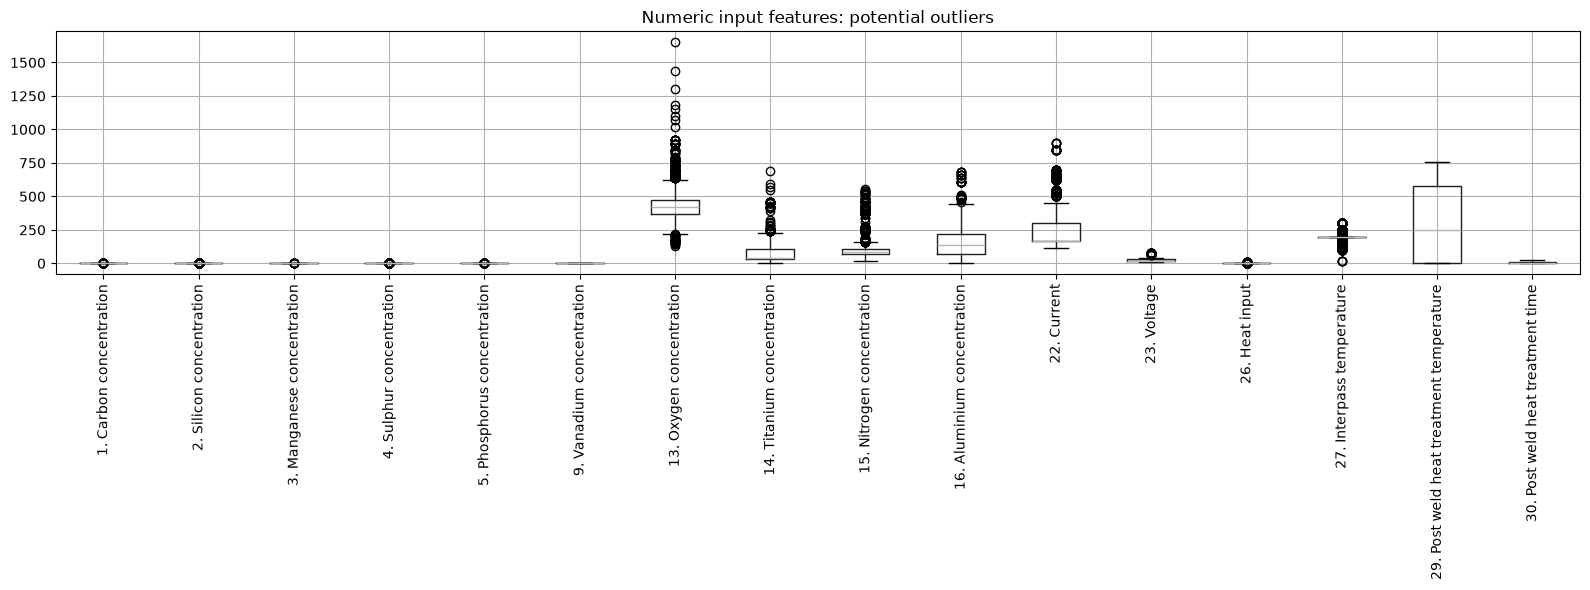

Feature scales before scaling (no scaling applied):


,feature,unit,schema_missing_percent,schema_min,schema_max,data_min,data_max,data_range,data_std,schema_note
column,,,,,,,,,,
13,Oxygen concentration,ppmw,23.97,132.000,1650.00,132.000,1650.00,1518.000,147.483825,
22,Current,A,15.01,115.000,900.00,115.000,900.00,785.000,192.560955,Missing jointly with Voltage (same 248 rows); ...
29,Post weld heat treatment temperature,°C,0.79,0.000,760.00,0.000,760.00,760.000,285.498003,0.0 in 610 rows (as-welded); otherwise common ...
14,Titanium concentration,ppmw,43.40,0.000,690.00,0.000,690.00,690.000,100.110707,Mix of plain ppmw values and '<' detection-lim...
16,Aluminium concentration,ppmw,45.22,0.004,680.00,0.004,680.00,679.996,155.781121,
15,Nitrogen concentration,ppmw,24.82,21.000,552.00,21.000,552.00,531.000,95.902889,59 rows use 'NNtotMMres' encoding (total vs re...
27,Interpass temperature,°C,0.00,20.000,300.00,20.000,300.00,280.000,39.550604,"'150-200' (38 rows) is a range token, not a si..."
23,Voltage,V,15.01,11.500,75.36,11.500,75.36,63.860,12.555629,
30,Post weld heat treatment time,hours,0.79,0.000,24.00,0.000,24.00,24.000,6.096034,0.0 in 610 rows (as-welded); pairs with col 29...


\n24. AC or DC (Welding parameter, current type: AC or DC)
Missing values: 215 (schema: 13.01%)
Rare categories (< 16 rows):


,count_in_data,count_in_schema


Category counts: data compared with columns.json


...

Schema note: Cross-check in data: '0' occurs only with AC (38 rows); '+' occurs with DC (1388) + a few AC (4); '-' only with DC (7). Jointly missing with col 24 on 156 rows.
\n28. Type of weld (Welding process: ShMA = MMA = manual metal arc; SA = SMA = submerged arc; FCA = flux cored arc; GTAA = gas tungsten arc automatic; GMAA = gas metal arc automatic; SAW-NG = submerged arc narrow gap; GMA-NG = gas metal arc narrow gap; ES = electroslag; TSA = tandem submerged arc)
Missing values: 0 (schema: 0.0%)
Rare categories (< 16 rows):


,count_in_data,count_in_schema
NGGMA,7,7
SAA,4,4
GTAA,4,4
GMAA,4,4


Category counts: data compared with columns.json


,count_in_data,count_in_schema
MMA,1140,1140
SA,261,261
FCA,87,87
TSA,87,87
ShMA,40,40
NGSAW,18,18
NGGMA,7,7
SAA,4,4
GTAA,4,4
GMAA,4,4


Schema note: File codes differ slightly from doc: SAW-NG appears as NGSAW, GMA-NG as NGGMA; SAA (4 rows) is an undocumented variant of SA; ShMA and MMA both mean manual metal arc (keep separate or merge as modelling choice). ES listed in doc but absent from data. Heavily imbalanced toward MMA.


In [4]:
# Use the schema in columns.json to select documented input features.
seuil_manquants = 50
metadonnees_entrees = {
    int(numero): infos
    for numero, infos in colonnes.items()
    if infos["role"] == "input"
}
colonnes_exclues = {
    numero: infos
    for numero, infos in metadonnees_entrees.items()
    if infos["missing"]["pct"] >= seuil_manquants
}

print(f"Input columns excluded for >= {seuil_manquants}% missing values:")
display(pd.DataFrame([
    {
        "column": numero,
        "feature": infos["label"],
        "missing_percent_in_schema": infos["missing"]["pct"],
    }
    for numero, infos in colonnes_exclues.items()
]).set_index("column"))

# Inspect remaining inputs only; the original DataFrame is not modified.
colonnes_a_examiner = {
    numero: infos
    for numero, infos in metadonnees_entrees.items()
    if numero not in colonnes_exclues
}
X_a_examiner = df[[f"{numero}. {infos['label']}" for numero, infos in colonnes_a_examiner.items()]].copy()
colonnes_categorielles = [
    f"{numero}. {infos['label']}"
    for numero, infos in colonnes_a_examiner.items()
    if infos["type"] == "categorical"
]
colonnes_numeriques = [
    f"{numero}. {infos['label']}"
    for numero, infos in colonnes_a_examiner.items()
    if infos["type"].startswith("continuous")
]

# Parse what is plainly numeric. Special encodings stay visible in the token report.
numerique = X_a_examiner[colonnes_numeriques].apply(pd.to_numeric, errors="coerce")

# 1. Flag potential outliers with the IQR rule; do not remove or cap them.
q1 = numerique.quantile(0.25)
q3 = numerique.quantile(0.75)
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr
masque_outliers = numerique.lt(borne_basse) | numerique.gt(borne_haute)

resume_outliers = pd.DataFrame({
    "feature": [colonnes[str(numero)]["label"] for numero in range(1, 1)],
})
resume_outliers = pd.DataFrame({
    "outlier_count": masque_outliers.sum(),
    "outlier_percent_of_numeric_values": (
        masque_outliers.sum() / numerique.notna().sum() * 100
    ).round(2),
    "lower_bound": borne_basse,
    "upper_bound": borne_haute,
})
resume_outliers["feature"] = [
    colonnes_a_examiner[int(name.split(".", 1)[0])]["label"]
    for name in resume_outliers.index
]
resume_outliers["unit"] = [
    colonnes_a_examiner[int(name.split(".", 1)[0])]["unit"]
    for name in resume_outliers.index
]
print("Potential numeric outliers (IQR rule; for review only):")
display(
    resume_outliers[resume_outliers["outlier_count"] > 0]
    .sort_values("outlier_count", ascending=False)
)

# Show tokens that could not be parsed and the schema notes explaining their format.
token_rows = []
for column in colonnes_numeriques:
    invalid = X_a_examiner[column].notna() & numerique[column].isna()
    if invalid.any():
        numero = int(column.split(".", 1)[0])
        infos = colonnes_a_examiner[numero]
        token_rows.append({
            "column": numero,
            "feature": infos["label"],
            "count": int(invalid.sum()),
            "examples_in_data": X_a_examiner.loc[invalid, column].astype(str).unique()[:8].tolist(),
            "documented_tokens": infos["observed"].get("censored_tokens", infos["observed"].get("non_numeric_tokens", [])),
            "schema_note": infos["observed"].get("note", ""),
        })
print("Non-numeric tokens in numeric inputs (check schema notes before parsing):")
display(pd.DataFrame(token_rows).set_index("column") if token_rows else pd.DataFrame())

# Boxplots help inspect the numeric ranges; they do not change any values.
plt.figure(figsize=(16, 6))
numerique.boxplot(rot=90)
plt.title("Numeric input features: potential outliers")
plt.tight_layout()
plt.show()

# 2. Compare measured ranges with the units and ranges documented in the schema.
echelle_rows = []
for column in colonnes_numeriques:
    numero = int(column.split(".", 1)[0])
    infos = colonnes_a_examiner[numero]
    observed = infos["observed"]
    echelle_rows.append({
        "column": numero,
        "feature": infos["label"],
        "unit": infos["unit"],
        "schema_missing_percent": infos["missing"]["pct"],
        "schema_min": observed.get("min", observed.get("numeric_range", {}).get("min")),
        "schema_max": observed.get("max", observed.get("numeric_range", {}).get("max")),
        "data_min": numerique[column].min(),
        "data_max": numerique[column].max(),
        "data_range": numerique[column].max() - numerique[column].min(),
        "data_std": numerique[column].std(),
        "schema_note": observed.get("note", ""),
    })
resume_echelles = pd.DataFrame(echelle_rows).set_index("column").sort_values(
    "data_range", ascending=False
)
print("Feature scales before scaling (no scaling applied):")
display(resume_echelles)

# 3. Compare observed categories with categories documented in columns.json.
for column in colonnes_categorielles:
    numero = int(column.split(".", 1)[0])
    infos = colonnes_a_examiner[numero]
    frequences = X_a_examiner[column].value_counts(dropna=False)
    categories_documentees = infos["observed"].get("categories", {})
    comparaison = pd.DataFrame({
        "count_in_data": frequences,
        "count_in_schema": pd.Series(categories_documentees),
    }).fillna(0).astype(int)
    rare_limit = max(5, int(0.01 * len(X_a_examiner)))
    print(f"\\n{numero}. {infos['label']} ({infos['details']})")
    print(f"Missing values: {X_a_examiner[column].isna().sum()} (schema: {infos['missing']['pct']}%)")
    print(f"Rare categories (< {rare_limit} rows):")
    display(comparaison[comparaison["count_in_data"] < rare_limit])
    print("Category counts: data compared with columns.json")
    display(comparaison)
    if infos["observed"].get("note"):
        print("Schema note:", infos["observed"]["note"])


## 2.3 Analyses complémentaires

Cinq vérifications qui orientent le pré-traitement et la modélisation (chiffres repris dans le rapport).

### 2.3.1 Valeurs manquantes : au hasard ou non ?

**Constat** : l'absence du nickel dépend de l'article (24 articles le donnent toujours, 21 jamais), et les lignes sans nickel diffèrent des autres (plus de soudage manuel, plus de soudures brutes). Les manquants **ne sont pas MCAR** (*missing completely at random*) : d'où deux traitements : les éléments d'alliage jamais rapportés par un article sont mis à 0 (3.7), les autres manquants sont imputés avec un indicateur « valeur manquante » (partie 4).

In [5]:
import sys
sys.path.insert(0, "preprocessing")
from ml_dataset import weld_source

article = df["44. Weld ID"].map(weld_source)
nickel_manquant = df["6. Nickel concentration"].isna()

# Part de lignes sans nickel dans chaque article
part_par_article = nickel_manquant.groupby(article).mean()
print(f"{article.nunique()} articles :")
print(f"  nickel toujours donné   : {(part_par_article == 0).sum()}")
print(f"  nickel jamais donné     : {(part_par_article == 1).sum()}")
print(f"  nickel donné en partie  : {((part_par_article > 0) & (part_par_article < 1)).sum()}")

# Si les valeurs manquaient au hasard (MCAR), les deux groupes se ressembleraient
procede = df["28. Type of weld"].replace({"ShMA": "MMA"})  # ShMA = MMA, même procédé
brut = (df["29. Post weld heat treatment temperature"] == 0) & (df["30. Post weld heat treatment time"] == 0)
comparaison = pd.DataFrame({
    "lignes": nickel_manquant.value_counts(),
    "soudage manuel MMA (%)": (procede == "MMA").groupby(nickel_manquant).mean() * 100,
    "brutes de soudage (%)": brut.groupby(nickel_manquant).mean() * 100,
    "limite d'élasticité moyenne (MPa)": df["31. Yield strength"].groupby(nickel_manquant).mean(),
}).rename(index={True: "nickel manquant", False: "nickel donné"}).rename_axis(None).round(0)
display(comparaison)

46 articles :
  nickel toujours donné   : 24
  nickel jamais donné     : 21
  nickel donné en partie  : 1


,lignes,soudage manuel MMA (%),brutes de soudage (%),limite d'élasticité moyenne (MPa)
nickel donné,697,49.0,21.0,531.0
nickel manquant,955,88.0,48.0,486.0


### 2.3.2 Lignes complètes

**Constat** : aucune ligne complète, même sur les 30 entrées. Supprimer les lignes incomplètes viderait la base.

In [6]:
entrees = df.columns[:30]
print("Lignes complètes sur les 44 colonnes :", df.notna().all(axis=1).sum())
print("Lignes avec les 30 entrées renseignées :", df[entrees].notna().all(axis=1).sum())

Lignes complètes sur les 44 colonnes : 0
Lignes avec les 30 entrées renseignées : 0


### 2.3.3 Une ligne = un essai, pas une soudure

Un même cordon donne plusieurs éprouvettes (traction, Charpy à plusieurs températures), chacune sur sa propre ligne.

**Constat** : 1652 lignes pour 624 recettes (1001 avec le traitement thermique). D'où trois choix :
- **un modèle par cible**, entraîné sur les lignes où elle est mesurée ;
- une **validation croisée groupée par article**, pour ne pas tester sur un cordon déjà vu ;
- la **température d'essai en entrée** du modèle Charpy.

In [7]:
cordons = df[df.columns[:28]].drop_duplicates()
etats = df[df.columns[:30]].drop_duplicates()
print(f"{len(df)} lignes")
print(f"  {len(cordons)} combinaisons distinctes de composition et de soudage (col. 1-28)")
print(f"  {len(etats)} en comptant aussi le traitement thermique (col. 1-30)")

# Exemple : un même cordon, une ligne de traction et quatre essais Charpy
display(df.loc[df["44. Weld ID"] == "Pat-1981-WB3/BX200",
               ["44. Weld ID", "29. Post weld heat treatment temperature",
                "31. Yield strength", "35. Charpy temperature", "36. Charpy impact toughness"]])

1652 lignes
  624 combinaisons distinctes de composition et de soudage (col. 1-28)
  1001 en comptant aussi le traitement thermique (col. 1-30)


,44. Weld ID,29. Post weld heat treatment temperature,31. Yield strength,35. Charpy temperature,36. Charpy impact toughness
960,Pat-1981-WB3/BX200,0.0,391.0,NaN,NaN
961,Pat-1981-WB3/BX200,0.0,NaN,-60.0,39.0
962,Pat-1981-WB3/BX200,0.0,NaN,-50.0,43.0
963,Pat-1981-WB3/BX200,0.0,NaN,-20.0,95.0
964,Pat-1981-WB3/BX200,0.0,NaN,0.0,114.0


### 2.3.4 Traitement à 250 °C pendant 14 h

Probablement un dégazage de l'hydrogène, pas un vrai traitement thermique (550 à 750 °C).

**Constat** : 333 lignes, mais aucun cordon testé avant et après : l'effet n'est pas mesurable. Ce traitement est codé par un indicateur 0/1 distinct (partie 4).

In [8]:
import numpy as np

t, h = df["29. Post weld heat treatment temperature"], df["30. Post weld heat treatment time"]
degazage = (t == 250) & (h == 14)
traction = df["31. Yield strength"].notna()
charpy = df["36. Charpy impact toughness"].notna()
print(f"Lignes à 250 °C / 14 h : {degazage.sum()} (traction : {(degazage & traction).sum()}, "
      f"Charpy : {(degazage & charpy).sum()})")

# Peut-on mesurer son effet ? Il faudrait un même cordon testé en traction à 0/0 ET à 250/14
etat = pd.Series(np.select([brut, degazage], ["brut", "250/14"], "autre"), index=df.index)
paires = etat[traction].groupby([df.loc[traction, c] for c in df.columns[:28]], dropna=False).agg(set)
print("Cordons testés en traction à la fois bruts et à 250 °C / 14 h :",
      paires.map(lambda e: {"brut", "250/14"} <= e).sum())

Lignes à 250 °C / 14 h : 333 (traction : 229, Charpy : 104)
Cordons testés en traction à la fois bruts et à 250 °C / 14 h : 0


### 2.3.5 Énergies Charpy à valeurs fixes

**Constat** : 356 lignes valent exactement 100 J et 118 exactement 28 J (articles d'Evans). Ce sont probablement les températures où l'énergie atteint 100 J ou 28 J, et non des énergies mesurées (à vérifier dans les articles).

In [9]:
energie = df["36. Charpy impact toughness"]
print("Valeurs les plus fréquentes de l'énergie Charpy :")
display(energie.value_counts().head(5).rename("lignes").to_frame())
print(f"Exactement 100 J : {(energie == 100).sum()} lignes ; exactement 28 J : {(energie == 28).sum()}")
print("Articles concernés (100 J ou 28 J) :")
display(article[energie.isin([100, 28])].value_counts().rename("lignes").to_frame().head(10))

Valeurs les plus fréquentes de l'énergie Charpy :


,lignes
36. Charpy impact toughness,
100.0,356
28.0,118
50.0,16
35.0,12
70.0,12


Exactement 100 J : 356 lignes ; exactement 28 J : 118
Articles concernés (100 J ou 28 J) :


,lignes
44. Weld ID,
EvansLetter,104
Evans-AlTi-1994,60
Evans-Nb/Mn-1991,40
Evans-Ti/Mn-1992,40
Evans-V/Mn-1991,39
Evans-Al/CMn-1990,35
Evans-Cr/CMn-1989,31
Evans-Ni/CMn-1990/1991,30
Evans-Ti/CMn-1992,20


## 2.4 Bilan : des constats aux traitements

| Constat | Traitement | Partie |
|---|---|---|
| Codes `<x`, `NNtotMMres`, `150-200` | conversion en nombres | 3.1 à 3.3 |
| Type de courant manquant, procédés rares | déduction, regroupements | 3.4 |
| 13 traitements thermiques inconnus | traitement du même article | 3.5 |
| Colonnes trop vides | exclues | 3.6 |
| Éléments d'alliage (Ni, Cr, Mo, V, Nb) jamais rapportés par un article | mis à 0 | 3.7 |
| Autres manquants (O, N, Ti, Al, soudage, manques isolés) | médiane + indicateur | 4 |
| Échelles différentes, catégories | standardisation, one-hot | 4 |
| Plusieurs lignes par cordon et par article | validation croisée groupée | 4 |
| Valeurs extrêmes | conservées | — |

# 3. Pré-traitement (étapes 1 à 5b)

Chaque étape corrige un défaut avec un script de `preprocessing/`, écrit son résultat dans `data/intermediate/` et le vérifie (`assert`). L'étape 5 assemble le tout ; juste avant l'écriture, l'étape 5b met à 0 les éléments d'alliage qu'un article ne rapporte jamais. Le fichier brut n'est jamais modifié.

```
welddb.data ─► étapes 1 à 4b ─► data/intermediate/ ─► étapes 5 et 5b ─► data/cleaned/cleaned.csv
```

## 3.1 Étape 1 — Valeurs sous la limite de détection `<x`

- **Constat** : `<0.002` signifie « sous la limite de détection 0,002 » : la valeur est entre 0 et 0,002, ni nulle ni manquante.
- **Règle** (`decensor.py`) : `<x` → `x` (borne haute ; alternative : `x/2`). Trois limites exprimées dans une autre unité sont corrigées (`UNIT_FIX`) : V `<5` = 5 ppm, Ti et Al `<0.01` = 0,01 %.
- **Résultat** : 1576 remplacements sur 14 colonnes.
- **Limite** : pics artificiels aux limites (par exemple 343 lignes d'aluminium à 5,0) ; tester `x/2` si ces lignes pèsent dans un modèle.

In [10]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from decensor import main

# Applies '<x' -> x and writes data/intermediate/decensored.csv
counts = main()

# Round-trip check: 1652 data rows, no '<' token left in value columns
rows = list(csv.reader(open("data/intermediate/decensored.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all(not c.startswith("<") for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no '<' token left, header:", rows[0][:4], "...")

Concerned columns (14): 4, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21, 39
Replacements '<x' -> x per column: col04=7, col08=2, col09=308, col10=14, col11=21, col12=12, col14=70, col16=403, col17=419, col18=299, col19=5, col20=8, col21=6, col39=2 (total 1576)
Wrote data/intermediate/decensored.csv: 1652 rows x 15 columns
Unit fix: col09 '<5' -> 0.0005 (limit given in another unit, see UNIT_FIX)
Unit fix: col14 '<0.01' -> 100.0 (limit given in another unit, see UNIT_FIX)
Unit fix: col16 '<0.01' -> 100.0 (limit given in another unit, see UNIT_FIX)
Examples (weld_id | column | raw -> new):
  Evans-Al/CMn-1990-<5aw | col09_Vanadium_concentration | <0.0005 -> 0.0005
  Evans-Al/CMn-1990-<5aw | col16_Aluminium_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5aw | col17_Boron_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5aw | col18_Niobium_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5awch1 | col09_Vanadium_concentration | <0.0005 -> 0.0005
  Evans-Al/CMn-1990-<5awch1 | col16_Aluminium_con

## 3.2 Étape 2 — Azote noté `NNtotMMres`

- **Constat** : 59 lignes notent `67tot33res`, soit 67 ppm d'azote total dont 33 d'azote résiduel.
- **Règle** (`nitrogen_total.py`) : on garde le total (`67`), seule grandeur comparable aux autres lignes.
- **Limite** : l'information sur l'azote résiduel est perdue.

In [11]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from nitrogen_total import main

# Keeps NN from 'NNtotMMres' and writes data/intermediate/nitrogen_total.csv
counts = main()

# Round-trip check: 1652 data rows, no 'tot' token left
rows = list(csv.reader(open("data/intermediate/nitrogen_total.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all("tot" not in c for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no 'tot' token left, header:", rows[0])

Concerned columns: [15] (tokens matching NNtotMMres)
Replacements NNtotMMres -> NN: 48tot18res-> 48 (x7), 50tot17res-> 50 (x7), 52tot18res-> 52 (x7), 54tot24res-> 54 (x7), 54totndres-> 54 (x6), 61tot34res-> 61 (x7), 66totndres-> 66 (x11), 67tot33res-> 67 (x7) (total 59)
Wrote data/intermediate/nitrogen_total.csv: 1652 rows x 2 columns
Examples (weld_id | raw -> new):
  Evans-Al/CMn-1990-<5aw | 67tot33res -> 67
  Evans-Al/CMn-1990-<5awch1 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5awch2 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5aw | 67tot33res -> 67
  Evans-Al/CMn-1990-<5ht | 67tot33res -> 67
  Evans-Al/CMn-1990-<5htch1 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5htch2 | 67tot33res -> 67
  Evans-Al/CMn-1990-20aw | 66totndres -> 66
check: 1652 data rows, no 'tot' token left, header: ['weld_id', 'col15_Nitrogen_concentration']


## 3.3 Étape 3 — Température entre passes notée `150-200`

- **Constat** : la température entre passes est celle du métal avant de déposer la passe suivante, dans une soudure en plusieurs passes. 38 lignes (article `PantK-1990`) la donnent sous forme d'intervalle.
- **Règle** (`interpass_range.py`) : milieu de l'intervalle, `175`.

In [12]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from interpass_range import main

# Replaces 'xx-yy' with the range mean and writes data/intermediate/interpass_mean.csv
counts = main()

# Round-trip check: 1652 data rows, no range token left in value columns
rows = list(csv.reader(open("data/intermediate/interpass_mean.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all("-" not in c for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no range token left, header:", rows[0])

Concerned columns: [27] (tokens matching xx-yy)
Replacements xx-yy -> mean: 150-200 -> 175.0 (x38) (total 38)
Wrote data/intermediate/interpass_mean.csv: 1652 rows x 2 columns
Examples (weld_id | raw -> new):
  PantK-1990-w1 | 150-200 -> 175.0
  PantK-1990-w2 | 150-200 -> 175.0
  PantK-1990-w3 | 150-200 -> 175.0
  PantK-1990-w4.0 | 150-200 -> 175.0
  PantK-1990-w4.1 | 150-200 -> 175.0
  PantK-1990-w4.2 | 150-200 -> 175.0
  PantK-1990-w4.3 | 150-200 -> 175.0
  PantK-1990-w4.4 | 150-200 -> 175.0
check: 1652 data rows, no range token left, header: ['weld_id', 'col27_Interpass_temperature']


## 3.4 Étape 4 — Variables catégorielles (colonnes 24 et 28)

- **Type de courant** (`categorical_clean.py`) : manquant sur 215 lignes, mais déduit de la polarité (`+` ou `-` → DC, `0` → AC). 59 lignes sont complétées ; 156 restent manquantes (catégorie `missing`, partie 4).
- **Procédé de soudage** : les synonymes et les niveaux trop rares pour être appris sont regroupés.

| Codes d'origine | Lignes | Niveau final | Raison |
|---|---|---|---|
| `ShMA` | 40 | `MMA` | synonyme (soudage manuel à l'arc) |
| `SAA`, `NGSAW` | 4 + 18 | `SA` | variantes de l'arc submergé |
| `GTAA`, `GMAA`, `NGGMA` | 4 + 4 + 7 | `GSA` | arc sous gaz, trop rares séparément |

**Résultat** : 5 procédés, `MMA` (1180), `SA` (283), `FCA` (87), `TSA` (87), `GSA` (15).

In [13]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from categorical_clean import main

# Fills col 24 from polarity, groups col 28 and writes data/intermediate/categorical.csv
inferred, merged = main()

# Check: 1652 rows, only DC/AC/empty in col 24, only the 5 grouped levels in col 28
rows = list(csv.DictReader(open("data/intermediate/categorical.csv", encoding="utf-8")))
assert len(rows) == 1652
assert {r["col24_AC_or_DC"] for r in rows} == {"DC", "AC", ""}
assert {r["col28_Type_of_weld"] for r in rows} == {"MMA", "SA", "TSA", "FCA", "GSA"}
print("check: 1652 rows, col 24 in {DC, AC, missing}, col 28 in 5 levels")


col 24 filled from polarity: + -> DC (x59) (total 59); still missing: 156
col 28 merged: GMAA -> GSA (x4), GTAA -> GSA (x4), NGGMA -> GSA (x7), NGSAW -> SA (x18), SAA -> SA (x4), ShMA -> MMA (x40) (total 77)
col 28 levels: MMA=1180, SA=283, FCA=87, TSA=87, GSA=15
Wrote data/intermediate/categorical.csv: 1652 rows x 3 columns
check: 1652 rows, col 24 in {DC, AC, missing}, col 28 in 5 levels


## 3.5 Étape 4b — Traitements thermiques inconnus (colonnes 29 et 30)

- **Constat** : 13 lignes `Gar&K-1975-25mm-…ht` n'ont ni température ni durée, alors que `ht` signifie *heat-treated*. La médiane (250 °C, la valeur du dégazage) serait fausse.
- **Règle** (`heat_treatment.py`) : traitement des autres soudures du même article, 600 °C pendant 0,75 h.
- **Limite** : c'est une hypothèse (plaques plus épaisses, traitement peut-être plus long), signalée dans le rapport.

In [14]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from heat_treatment import main

# Fills the 13 unknown treatments and writes data/intermediate/heat_treatment.csv
filled = main()

rows = list(csv.DictReader(open("data/intermediate/heat_treatment.csv", encoding="utf-8")))
assert len(rows) == 1652 and len(filled) == 13
assert all(r["col29_Post_weld_heat_treatment_temperature"] != "" for r in rows)
print("check: 1652 rows, no unknown heat treatment left")

Unknown treatment filled from the same article (600 degC, 0.75 h): 13 rows (Gar&K-1975-25mm-1ht ... Gar&K-1975-25mm-13ht); still missing: 0
Wrote data/intermediate/heat_treatment.csv: 1652 rows x 3 columns
check: 1652 rows, no unknown heat treatment left


## 3.6 Étape 5 — Assemblage dans `cleaned.csv`

`build_model_table.py` prend pour chaque colonne la version corrigée si elle existe, sinon la valeur brute, et retire les 14 colonnes écartées en 2.1 (`DROPPED`). Les tables sont assemblées ligne à ligne, car un même `weld_id` se répète ; le script vérifie l'ordre des lignes et les noms de colonnes. Juste avant d'écrire le fichier, il applique l'étape 5b (partie 3.7).

**Résultat** : 1652 lignes × 30 colonnes, dans cet ordre : `weld_id`, les 23 entrées, la température d'essai Charpy (une entrée du seul modèle Charpy), puis les 5 cibles. Les éléments d'alliage non rapportés sont traités en 3.7, les autres manquants et les échelles en partie 4.

In [15]:
import csv
import re
import sys
sys.path.insert(0, "preprocessing")
from build_model_table import main as assemble

# Joins intermediate/ + raw fallback (minus DROPPED) into data/cleaned/cleaned.csv
assemble()

# Check: shape and no dropped column present
rows = list(csv.reader(open("data/cleaned/cleaned.csv", encoding="utf-8")))
dropped = {10, 11, 12, 17, 19, 20, 21, 37, 38, 39, 40, 41, 42, 43}
nums = [int(re.match(r"col(\d+)_", h).group(1)) for h in rows[0][1:]]
assert len(rows) == 1653 and not (set(nums) & dropped)
print("check: 1652 data rows x", len(rows[0]), "columns, none dropped present")

Intermediate files joined (5): categorical.csv, decensored.csv, heat_treatment.csv, interpass_mean.csv, nitrogen_total.csv
  categorical.csv: 2 columns [24, 28]
  decensored.csv: 6 columns [4, 8, 9, 14, 16, 18]
  heat_treatment.csv: 2 columns [29, 30]
  interpass_mean.csv: 1 columns [27]
  nitrogen_total.csv: 1 columns [15]
  raw: 17 columns [1, 2, 3, 5, 6, 7, 13, 22, 23, 25, 26, 31, 32, 33, 34, 35, 36]
Wrote data/cleaned/cleaned.csv: 1652 rows x 30 columns
Dropped per notebook decision (14): [10, 11, 12, 17, 19, 20, 21, 37, 38, 39, 40, 41, 42, 43]
check: 1652 data rows x 30 columns, none dropped present


## 3.7 Étape 5b — Éléments d'alliage jamais rapportés par un article → 0

- **Constat** : Ni, Cr, Mo, V et Nb sont des ajouts volontaires. Un article les donne pour toutes ses soudures ou pour aucune (2.3.1) : « non rapporté » veut dire « non ajouté », soit une teneur quasi nulle. Les soudures C-Mn qui les rapportent ont d'ailleurs des teneurs résiduelles (Ni, Cr : médiane 0 %), loin des médianes de toutes les valeurs rapportées (Cr 0,53 %, Mo 0,34 %) qu'imputerait la partie 4.
- **Règle** (`alloy_zero.py`, appelée par `build_model_table.py`) : pour chaque article, pris avant toute fusion d'articles, un élément absent de toutes ses lignes est mis à 0.
- **Non concernés** : les manques isolés (médiane, partie 4) ; O, N, Ti, Al et les paramètres de soudage, pour lesquels une absence ne veut pas dire zéro car ils sont nécessairement présents dans une soudure.
- **Sans fuite** : la règle n'apprend aucune statistique et ne regarde qu'un article, dont toutes les lignes restent dans le même pli ; elle s'applique donc une fois, avant la séparation entraînement / test.

La cellule suivante compare les manquants avant et après, et vérifie que les manques restants sont isolés.

In [ ]:
import sys
import pandas as pd
sys.path.insert(0, "preprocessing")
from ml_dataset import weld_source

propre = pd.read_csv("data/cleaned/cleaned.csv")
assert (propre["weld_id"].values == df["44. Weld ID"].values).all()  # mêmes lignes, même ordre
article_propre = propre["weld_id"].map(weld_source)

bilan = []
for nom, numero in {"Ni": 6, "Cr": 7, "Mo": 8, "V": 9, "Nb": 18}.items():
    col_brut = next(c for c in df.columns if c.startswith(f"{numero}. "))
    col_propre = next(c for c in propre.columns if c.startswith(f"col{numero:02d}_"))
    manquant_avant = df[col_brut].isna()
    manquant_apres = propre[col_propre].isna()
    mis_a_zero = manquant_avant & ~manquant_apres
    assert (propre.loc[mis_a_zero, col_propre] == 0).all()
    # Chaque manque restant est isolé : son article rapporte l'élément sur d'autres lignes
    rapporte = propre[col_propre].notna().groupby(article_propre).any()
    assert rapporte[article_propre[manquant_apres]].all()
    bilan.append({
        "élément": nom,
        "manquants avant": int(manquant_avant.sum()),
        "mis à 0": int(mis_a_zero.sum()),
        "articles mis à 0": article_propre[mis_a_zero].nunique(),
        "manquants restants (isolés)": int(manquant_apres.sum()),
    })
display(pd.DataFrame(bilan).set_index("élément"))
print("check: valeurs mises à 0 = 0, manques restants tous isolés")

# 4. Préparation pour la modélisation (étape 6)

`make_preprocessor(X)` (`preprocessing/ml_dataset.py`) renvoie un `ColumnTransformer` qui :
1. **impute** les variables numériques par la médiane et ajoute un indicateur 0/1 « valeur manquante » (les manquants dépendent de l'article, 2.3.1) ; pour Ni, Cr, Mo, V et Nb, il ne reste que quelques manques isolés, le reste ayant été mis à 0 en 3.7 ;
2. **standardise** les variables numériques ;
3. **encode en one-hot** les variables catégorielles (case vide → `missing`).

Ces transformations apprennent des statistiques (médianes, moyennes, écarts-types). Elles ne sont donc pas appliquées au fichier, mais placées en tête d'un `Pipeline` : apprises (`fit`) sur l'entraînement de chaque pli, puis appliquées (`transform`) au test, sans **fuite d'information**.

Deux autres fonctions :
- `load_cleaned()` lit `cleaned.csv` et ajoute `source` (l'article d'origine, 46 au total) ainsi que les indicateurs `as_welded` et `degassing_250C_14h` ;
- `get_xy(df, cible)` renvoie X, y et `groups` (l'article) sur les lignes où la cible est mesurée. Cibles : `yield` (780 lignes), `uts` (738), `elongation` (700), `roa` (705), `charpy` (879).

**Validation croisée** : `GroupKFold` avec `groups=source`, pour que les lignes d'un même article restent dans le même pli.

```python
X, y, groups = get_xy(load_cleaned(), "yield")
model = Pipeline([("prep", make_preprocessor(X)), ("reg", Ridge())])
cross_val_score(model, X, y, groups=groups, cv=GroupKFold(5))
```

La cellule suivante vérifie qu'il ne reste aucune case vide après préparation et qu'aucun article n'est partagé entre entraînement et test.

In [16]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
sys.path.insert(0, "preprocessing")
from ml_dataset import TARGETS, get_xy, load_cleaned, make_preprocessor

ml = load_cleaned()
print(f"{ml.shape[0]} rows, {ml['source'].nunique()} sources")
display(ml["source"].value_counts().rename("rows").to_frame().T)

summary = []
for target in TARGETS:
    X, y, groups = get_xy(ml, target)
    Xt = make_preprocessor(X).fit_transform(X)
    assert not np.isnan(Xt).any()
    # Leakage check: no source on both sides of any GroupKFold split
    for train, test in GroupKFold(n_splits=5).split(X, y, groups):
        assert not set(groups.iloc[train]) & set(groups.iloc[test])
    summary.append({
        "target": target, "column": TARGETS[target], "rows": len(y),
        "sources": groups.nunique(), "raw inputs": X.shape[1],
        "features after preprocessing": Xt.shape[1],
        "y mean": round(y.mean(), 1), "y std": round(y.std(), 1),
    })
display(pd.DataFrame(summary).set_index("target"))
print("check: no NaN after preprocessing, no source shared between train and test folds")

# Example of the transformed design matrix (fitted on all rows here for display only)
X, y, groups = get_xy(ml, "charpy")
prep = make_preprocessor(X).fit(X)
display(pd.DataFrame(prep.transform(X), columns=prep.get_feature_names_out(), index=X.index).head())


1652 rows, 46 sources


source,EvansLetter,Evans-AlTi-1994,Evans-StressRelief-1991,SvenGret-1990,Pat-1981,Mart,Gar&K-1975,Evans-V/Mn-1991,Evans-Nb/Mn-1991,Evans-Ti/Mn-1992,...,EPRI,Birmingham,Evans-Mn-1977,SurianEtAl-C-1991,Alekseev&-CMnNi-1991,Natsume-1990,Sw&Rog-1973,RC81033,Kik,Inag&-1966
rows,156,114,110,96,79,70,66,60,60,60,...,12,9,8,8,7,4,4,4,2,2


,column,rows,sources,raw inputs,features after preprocessing,y mean,y std
target,,,,,,,
yield,col31_Yield_strength,780,42,25,47,508.6,92.9
uts,col32_Ultimate_tensile_strength,738,41,25,47,594.4,88.6
elongation,col33_Elongation,700,36,25,47,26.3,4.9
roa,col34_Reduction_of_Area,705,34,25,47,71.8,8.9
charpy,col36_Charpy_impact_toughness,879,26,26,45,87.7,50.1


check: no NaN after preprocessing, no source shared between train and test folds


,col01_Carbon_concentration,col02_Silicon_concentration,col03_Manganese_concentration,col04_Sulphur_concentration,col05_Phosphorus_concentration,col06_Nickel_concentration,col07_Chromium_concentration,col08_Molybdenum_concentration,col09_Vanadium_concentration,col13_Oxygen_concentration,...,col24_AC_or_DC_DC,col24_AC_or_DC_missing,col25_Electrode_polarity_+,col25_Electrode_polarity_0,col25_Electrode_polarity_missing,col28_Type_of_weld_FCA,col28_Type_of_weld_GSA,col28_Type_of_weld_MMA,col28_Type_of_weld_SA,col28_Type_of_weld_TSA
1,-1.599779,-0.168835,-1.388286,-0.114921,-0.035620,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.599779,-0.168835,-1.388286,-0.114921,-0.035620,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.599779,-0.062527,-0.439411,-0.187437,0.045599,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,-1.599779,-0.062527,-0.439411,-0.187437,0.045599,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,-1.297731,0.362704,0.559405,-0.187437,0.045599,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# 5. Analyse descriptive des données nettoyées

Figures de la partie Données du rapport (`report/figures/`), calculées sur les valeurs décodées de `cleaned.csv`.

In [17]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA

sys.path.insert(0, "preprocessing")
from ml_dataset import TARGETS, input_columns, load_cleaned, make_preprocessor

FIGURES = Path("report/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
ENCRE, ENCRE_2, GRILLE = "#0b0b0b", "#52514e", "#e4e3df"
BLEU, ORANGE, AQUA, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#b5b3ad"
DIVERGENTE = LinearSegmentedColormap.from_list(
    "bleu_rouge", ["#104281", "#5598e7", "#f0efec", "#ec8a89", "#a32c2c"])
plt.rcParams.update({
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "axes.edgecolor": GRILLE, "axes.labelcolor": ENCRE_2, "axes.titlecolor": ENCRE,
    "xtick.color": ENCRE_2, "ytick.color": ENCRE_2, "text.color": ENCRE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRILLE, "grid.linewidth": 0.6,
    "legend.frameon": False, "savefig.bbox": "tight", "figure.dpi": 110,
})

ml = load_cleaned()
NOMS = {  # noms courts en français pour les figures
    "col01_Carbon_concentration": "C", "col02_Silicon_concentration": "Si",
    "col03_Manganese_concentration": "Mn", "col04_Sulphur_concentration": "S",
    "col05_Phosphorus_concentration": "P", "col06_Nickel_concentration": "Ni",
    "col07_Chromium_concentration": "Cr", "col08_Molybdenum_concentration": "Mo",
    "col09_Vanadium_concentration": "V", "col13_Oxygen_concentration": "O",
    "col14_Titanium_concentration": "Ti", "col15_Nitrogen_concentration": "N",
    "col16_Aluminium_concentration": "Al", "col18_Niobium_concentration": "Nb",
    "col22_Current": "Courant", "col23_Voltage": "Tension",
    "col26_Heat_input": "Énergie de soudage", "col27_Interpass_temperature": "T entre passes",
    "col29_Post_weld_heat_treatment_temperature": "T traitement",
    "col30_Post_weld_heat_treatment_time": "Durée traitement",
    "col31_Yield_strength": "Limite d'élasticité", "col32_Ultimate_tensile_strength": "Résistance",
    "col33_Elongation": "Allongement", "col34_Reduction_of_Area": "Striction",
    "col35_Charpy_temperature": "T essai Charpy", "col36_Charpy_impact_toughness": "Énergie Charpy",
}
numeriques = [c for c in input_columns(ml) if c in NOMS]

## 5.1 Valeurs manquantes par entrée

En gris, les entrées écartées en 2.1.

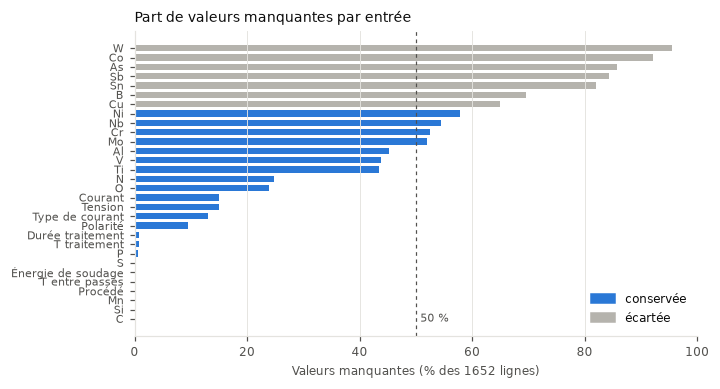

In [18]:
manquants = df[df.columns[:30]].isna().mean().mul(100).sort_values()
ecartees = {f"{n}." for n in (10, 11, 12, 17, 19, 20, 21)}
couleurs = [GRIS if nom.split(" ")[0] in ecartees else BLEU for nom in manquants.index]
fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.barh(range(len(manquants)), manquants.values, color=couleurs, height=0.7)
NOMS_ENTREES = {1: "C", 2: "Si", 3: "Mn", 4: "S", 5: "P", 6: "Ni", 7: "Cr", 8: "Mo", 9: "V",
                10: "Cu", 11: "Co", 12: "W", 13: "O", 14: "Ti", 15: "N", 16: "Al", 17: "B",
                18: "Nb", 19: "Sn", 20: "As", 21: "Sb", 22: "Courant", 23: "Tension",
                24: "Type de courant", 25: "Polarité", 26: "Énergie de soudage",
                27: "T entre passes", 28: "Procédé", 29: "T traitement", 30: "Durée traitement"}
ax.set_yticks(range(len(manquants)),
              [NOMS_ENTREES[int(n.split(".")[0])] for n in manquants.index], fontsize=7)
ax.set_xlabel("Valeurs manquantes (% des 1652 lignes)")
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False)
ax.axvline(50, color=ENCRE_2, linewidth=0.8, linestyle=(0, (3, 3)))
ax.text(50.8, 0, "50 %", color=ENCRE_2, fontsize=7, va="center")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=BLEU), plt.Rectangle((0, 0), 1, 1, color=GRIS)],
          labels=["conservée", "écartée"], loc="lower right")
ax.set_title("Part de valeurs manquantes par entrée", loc="left")
fig.savefig(FIGURES / "manquants.pdf"); plt.show()

## 5.2 Distribution des grandeurs à prédire

Les pics de l'énergie Charpy à 100 J et 28 J sont les valeurs fixes de 2.3.5.

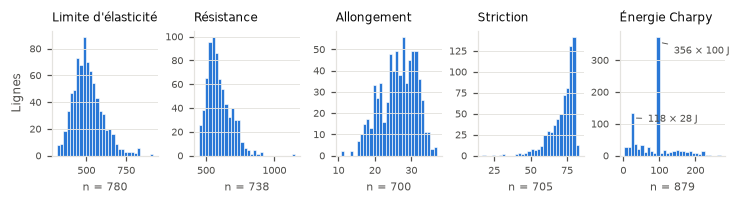

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(6.8, 1.9))
for ax, (cle, col) in zip(axes, TARGETS.items()):
    valeurs = ml[col].dropna()
    ax.hist(valeurs, bins=30, color=BLEU, edgecolor="white", linewidth=0.4)
    ax.set_title(NOMS[col], loc="left", fontsize=8)
    ax.set_xlabel(f"n = {len(valeurs)}", fontsize=7); ax.grid(axis="x", visible=False)
    ax.tick_params(labelsize=6.5)
axes[0].set_ylabel("Lignes")
pics = ml[TARGETS["charpy"]].value_counts()
for energie in (28, 100):
    axes[-1].annotate(f"{pics[energie]} × {energie} J", xy=(energie, pics[energie]),
                      xytext=(energie + 40, pics[energie] * 0.9), fontsize=6.5, color=ENCRE_2,
                      arrowprops=dict(arrowstyle="-", color=ENCRE_2, linewidth=0.6))
fig.tight_layout(w_pad=0.6)
fig.savefig(FIGURES / "cibles.pdf"); plt.show()

## 5.3 Corrélations entre entrées et grandeurs à prédire

Corrélation de Spearman, calculée sur les rangs : robuste aux valeurs extrêmes, elle capte les relations monotones.

**Constat** : Cr, Mo, V et Nb vont avec une résistance plus élevée (r de 0,41 à 0,55) et un allongement plus faible ; la tension, le courant, l'énergie de soudage, P et S avec une striction plus faible. Une corrélation ne prouve pas un lien de cause à effet.

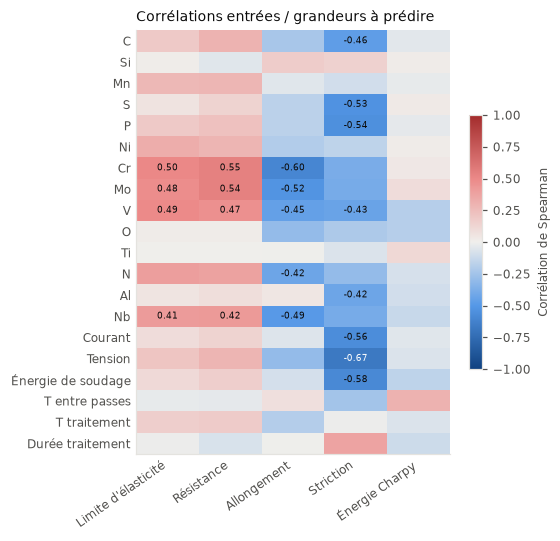

Corrélations les plus fortes (|r| >= 0.4) :


,,r
Tension,Striction,-0.67
Cr,Allongement,-0.60
Énergie de soudage,Striction,-0.58
Courant,Striction,-0.56
Cr,Résistance,0.55
Mo,Résistance,0.54
P,Striction,-0.54
S,Striction,-0.53
Mo,Allongement,-0.52
Cr,Limite d'élasticité,0.50


In [20]:
# Corrélation de Spearman (rangs : robuste aux valeurs extrêmes et aux relations non
# linéaires monotones), calculée sur les lignes où les deux variables sont renseignées.
sorties = list(TARGETS.values())
correlations = ml[numeriques + sorties].corr(method="spearman").loc[numeriques, sorties]
effectifs = ml[numeriques].notna().T.astype(int) @ ml[sorties].notna().astype(int)
correlations = correlations.where(effectifs >= 30)  # trop peu de lignes communes : non affiché
fig, ax = plt.subplots(figsize=(4.6, 5.0))
im = ax.imshow(correlations.values, cmap=DIVERGENTE, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(sorties)), [NOMS[c] for c in sorties], rotation=35, ha="right")
ax.set_yticks(range(len(numeriques)), [NOMS[c] for c in numeriques])
ax.grid(False); ax.tick_params(length=0)
for i in range(len(numeriques)):
    for j in range(len(sorties)):
        r = correlations.values[i, j]
        if np.isnan(r):
            ax.text(j, i, "–", ha="center", va="center", fontsize=6, color=ENCRE_2)
        elif abs(r) >= 0.4:
            ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(r) >= 0.6 else ENCRE)
fig.colorbar(im, ax=ax, shrink=0.6, label="Corrélation de Spearman")
ax.set_title("Corrélations entrées / grandeurs à prédire", loc="left")
fig.savefig(FIGURES / "correlations.pdf"); plt.show()
print("Corrélations les plus fortes (|r| >= 0.4) :")
display(correlations.stack().loc[lambda s: s.abs() >= 0.4].sort_values(key=abs, ascending=False)
        .rename(index=NOMS).round(2).to_frame("r"))

## 5.4 ACP sur les entrées numériques

Sur les 995 états de soudure distincts, manquants remplacés par la médiane, variables standardisées.

**Constat** : 2 axes expliquent 38 % de la variance et 5 axes 61 % : les entrées sont peu redondantes. L'axe 1 regroupe les éléments d'alliage (Cr, Mo, V, N, Nb) et la température de traitement.

995 états de soudure, 20 variables numériques
Variance expliquée (%) : [20.5 17.4  8.8  7.9  6.4  5.3] | cumulée 2 axes : 37.9 | 5 axes : 61.0


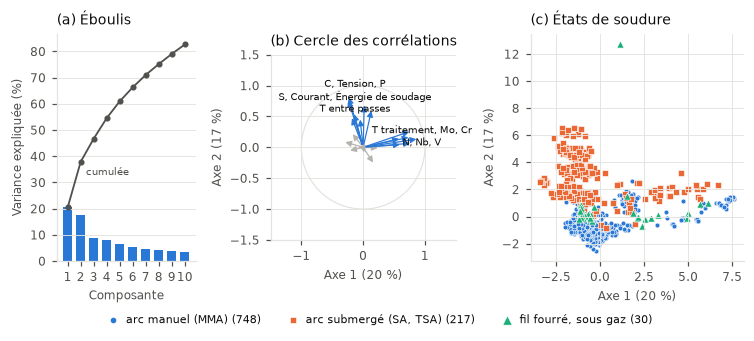

,axe 1,axe 2
Cr,0.91,0.14
Mo,0.81,0.07
V,0.79,0.27
N,0.78,0.17
T traitement,0.64,0.05
Nb,0.63,0.15
Mn,-0.34,0.10
O,0.29,-0.01


In [21]:
# Une ligne par état de soudure (composition + soudage + traitement) pour ne pas compter
# plusieurs fois un même métal testé à plusieurs températures ; valeurs manquantes
# complétées par la médiane puis standardisation (sans indicateurs : on veut décrire le
# métal, pas la façon dont il a été rapporté).
etats = ml.drop_duplicates(subset=input_columns(ml)).reset_index(drop=True)
X = etats[numeriques]
X_std = (X.fillna(X.median()) - X.fillna(X.median()).mean()) / X.fillna(X.median()).std()
acp = PCA().fit(X_std)
coords = acp.transform(X_std)
variance = acp.explained_variance_ratio_ * 100
print(f"{len(etats)} états de soudure, {len(numeriques)} variables numériques")
print("Variance expliquée (%) :", np.round(variance[:6], 1), "| cumulée 2 axes :",
      round(variance[:2].sum(), 1), "| 5 axes :", round(variance[:5].sum(), 1))

fig, axes = plt.subplots(1, 3, figsize=(6.9, 2.9), gridspec_kw={"width_ratios": [0.75, 1, 1.15]})
# (a) éboulis des valeurs propres
ax = axes[0]
ax.bar(range(1, 11), variance[:10], color=BLEU, width=0.7)
ax.plot(range(1, 11), np.cumsum(variance[:10]), color=ENCRE_2, linewidth=1.2, marker="o", markersize=3)
ax.set_xticks(range(1, 11)); ax.set_xlabel("Composante"); ax.set_ylabel("Variance expliquée (%)")
ax.set_title("(a) Éboulis", loc="left"); ax.grid(axis="x", visible=False)
ax.text(2.4, np.cumsum(variance[:10])[1] - 2, "cumulée", ha="left", va="top", fontsize=6.5, color=ENCRE_2)
# (b) cercle des corrélations
ax = axes[1]
charges = acp.components_[:2].T * np.sqrt(acp.explained_variance_[:2])
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color=GRILLE, linewidth=0.8))
fortes = []
for (x, y), col in zip(charges, numeriques):
    fort = np.hypot(x, y) >= 0.5
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=BLEU if fort else GRIS, linewidth=0.8))
    if fort:
        fortes.append((np.arctan2(y, x), x, y, NOMS[col]))
# Flèches de directions proches : une seule étiquette, placée au bout du groupe
fortes.sort()
groupes = [[fortes[0]]]
for f in fortes[1:]:
    (groupes[-1].append(f) if f[0] - groupes[-1][-1][0] < np.radians(30) else groupes.append([f]))
for g in groupes:
    xm, ym = np.mean([f[1] for f in g]), np.mean([f[2] for f in g])
    noms = [f[3] for f in g]
    texte = "\n".join(", ".join(noms[i:i + 3]) for i in range(0, len(noms), 3))
    ax.text(xm * 1.25, ym * 1.25, texte, fontsize=6.3, ha="center", va="center", color=ENCRE)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal")
ax.set_xlabel(f"Axe 1 ({variance[0]:.0f} %)"); ax.set_ylabel(f"Axe 2 ({variance[1]:.0f} %)")
ax.set_title("(b) Cercle des corrélations", loc="left")
# (c) projection des états de soudure, par famille de procédé
ax = axes[2]
famille = etats["col28_Type_of_weld"].replace({"TSA": "SA", "FCA": "Autres", "GSA": "Autres"})
libelles = {"MMA": "arc manuel (MMA)", "SA": "arc submergé (SA, TSA)", "Autres": "fil fourré, sous gaz"}
for nom, couleur, marqueur, taille in [("MMA", BLEU, "o", 10), ("SA", ORANGE, "s", 12),
                                       ("Autres", AQUA, "^", 22)]:
    m = (famille == nom).values
    ax.scatter(coords[m, 0], coords[m, 1], s=taille, color=couleur, marker=marqueur,
               edgecolor="white", linewidth=0.4, label=f"{libelles[nom]} ({m.sum()})")
ax.set_xlabel(f"Axe 1 ({variance[0]:.0f} %)"); ax.set_ylabel(f"Axe 2 ({variance[1]:.0f} %)")
ax.set_title("(c) États de soudure", loc="left")
fig.legend(*ax.get_legend_handles_labels(), loc="lower center", ncol=3, fontsize=7,
           handletextpad=0.2, markerscale=1.3, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(w_pad=0.8)
fig.savefig(FIGURES / "acp.pdf"); plt.show()

# Variables les plus liées aux deux premiers axes
display(pd.DataFrame(charges, index=[NOMS[c] for c in numeriques], columns=["axe 1", "axe 2"])
        .round(2).sort_values("axe 1", key=abs, ascending=False).head(8))

## 5.5 Liens entre les grandeurs à prédire

**Constat** : limite d'élasticité et résistance à la traction presque redondantes (r = 0,93) ; résistance et ductilité opposées (r de −0,57 à −0,78) ; Charpy : 405 énergies mesurées et 474 fixées.

D'où trois cibles principales proposées : **limite d'élasticité**, **allongement** et **énergie Charpy**.

In [22]:
traction = [TARGETS[k] for k in ("yield", "uts", "elongation", "roa")]
liens = ml[traction].corr(method="spearman").rename(index=NOMS, columns=NOMS).round(2)
display(liens)
lignes_communes = ml[traction].notna().astype(int)
display((lignes_communes.T @ lignes_communes).rename(index=NOMS, columns=NOMS)
        .rename_axis("lignes communes"))

charpy = ml[ml[TARGETS["charpy"]].notna()]
fixee = charpy[TARGETS["charpy"]].isin([100, 28])
display(pd.DataFrame({
    "lignes": [(~fixee).sum(), fixee.sum()],
    "articles": [charpy.loc[~fixee, "source"].nunique(), charpy.loc[fixee, "source"].nunique()],
}, index=["énergie mesurée", "énergie fixée (100 J / 28 J)"]))

,Limite d'élasticité,Résistance,Allongement,Striction
Limite d'élasticité,1.00,0.93,-0.71,-0.57
Résistance,0.93,1.00,-0.78,-0.73
Allongement,-0.71,-0.78,1.00,0.62
Striction,-0.57,-0.73,0.62,1.00


,Limite d'élasticité,Résistance,Allongement,Striction
lignes communes,,,,
Limite d'élasticité,780,714,691,696
Résistance,714,738,666,671
Allongement,691,666,700,685
Striction,696,671,685,705


,lignes,articles
énergie mesurée,405,13
énergie fixée (100 J / 28 J),474,17


## 5.6 Énergie de soudage, courant et tension

**Constat** : fortement corrélés (r de 0,72 à 0,80), car l'énergie de soudage se calcule à partir du courant et de la tension. Un modèle régularisé ou à base d'arbres y est moins sensible.

In [23]:
soudage = ["col22_Current", "col23_Voltage", "col26_Heat_input"]
display(ml[soudage].corr(method="spearman").rename(index=NOMS, columns=NOMS).round(2))

,Courant,Tension,Énergie de soudage
Courant,1.00,0.73,0.80
Tension,0.73,1.00,0.72
Énergie de soudage,0.80,0.72,1.00


# 6. Bilan et suite

- **Acquis** : base comprise, défauts corrigés (`cleaned.csv`), préparation sans fuite avec validation croisée groupée par article, figures du rapport.
- **À valider** : le protocole d'évaluation (validation croisée imbriquée ou articles mis de côté) ; les trois cibles et le traitement des énergies Charpy fixées ; les seuils d'une bonne soudure (normes) ; les hypothèses `<x` → `x`, azote total, étape 4b et étape 5b (« non rapporté » = 0).
- **Suite** : comparer plusieurs familles de modèles avec le même protocole, appliquer au moins une méthode semi-supervisée, choisir le modèle et formuler des recommandations.